# Weighted Unsupervised Feature Quality Analysis: Hierarchical Clustering

This notebook evaluates the quality of **weighted** normalized behavioral biometric features using **Agglomerative Hierarchical Clustering**. 

## Objective:
Determine if applying feature importance weights improves the distinctiveness of behavioral signatures. We focus on the **Ward Linkage + Euclidean Distance** configuration, which was previously identified as the best performing model for this dataset.

## Methodology:
1. **Load Weighted Data**: Load the dataset where features have been multiplied by their Random Forest importance values.
2. **Filter Data**: Select only legitimate sessions (`label == 1`).
3. **Clustering**: Perform Hierarchical Clustering using Ward's method and Euclidean distance.
4. **Evaluation**: Compare results against actual User IDs using Adjusted Rand Index (ARI), Silhouette Score, and Cluster Purity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score, silhouette_score
import os

# Set plotting style
sns.set_theme(style="whitegrid")

## 1. Data Loading and Preparation

We load the weighted normalized feature extraction file and isolate the target variable (`user_id`).

In [2]:
data_path = r'../../data_processed/feature_kmt_dataset_Edge_Hill_University_22/feature_importance_ranking/weighted_normalized_feature_extraction_V4_88_users.csv'

if not os.path.exists(data_path):
    print(f"Error: {data_path} not found.")
else:
    df_full = pd.read_csv(data_path)
    
    # Filter for label 1 (Legitimate User Data)
    df = df_full[df_full['label'] == 1].copy()
    
    # Handle Non-Finite Values (NaN/Inf)
    df_numeric = df.drop(columns=['user_id', 'label'])
    df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    print(f"Weighted Dataset Loaded: {data_path}")
    print(f"Filtered Data (Label 1) Shape: {df.shape}")
    print(f"Unique Users: {df['user_id'].nunique()}")
    
    # Prepare Ground Truth and Feature Matrix
    X = df_numeric.values
    y_true = df['user_id'].values

Weighted Dataset Loaded: ../../data_processed/feature_kmt_dataset_Edge_Hill_University_22/feature_importance_ranking/weighted_normalized_feature_extraction_V4_88_users.csv
Filtered Data (Label 1) Shape: (880, 113)
Unique Users: 88


## 2. Ward + Euclidean Clustering Analysis

Ward's method is a variance-minimizing approach. In behavioral biometrics, it effectively groups sessions by minimizing the total within-cluster sum of squares.

In [3]:
print("Running Hierarchical Clustering (Ward + Euclidean)...")

# Compute Linkage Matrix
Z = linkage(X, method='ward', metric='euclidean')

# Form 88 Clusters (matching the number of users)
clusters = fcluster(Z, t=88, criterion='maxclust')

# Calculate Metrics
ari = adjusted_rand_score(y_true, clusters)
silhouette = silhouette_score(X, clusters)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Running Hierarchical Clustering (Ward + Euclidean)...
Adjusted Rand Index (ARI): 0.3356
Silhouette Score: 0.1332


## 3. Visualization

### Dendrogram

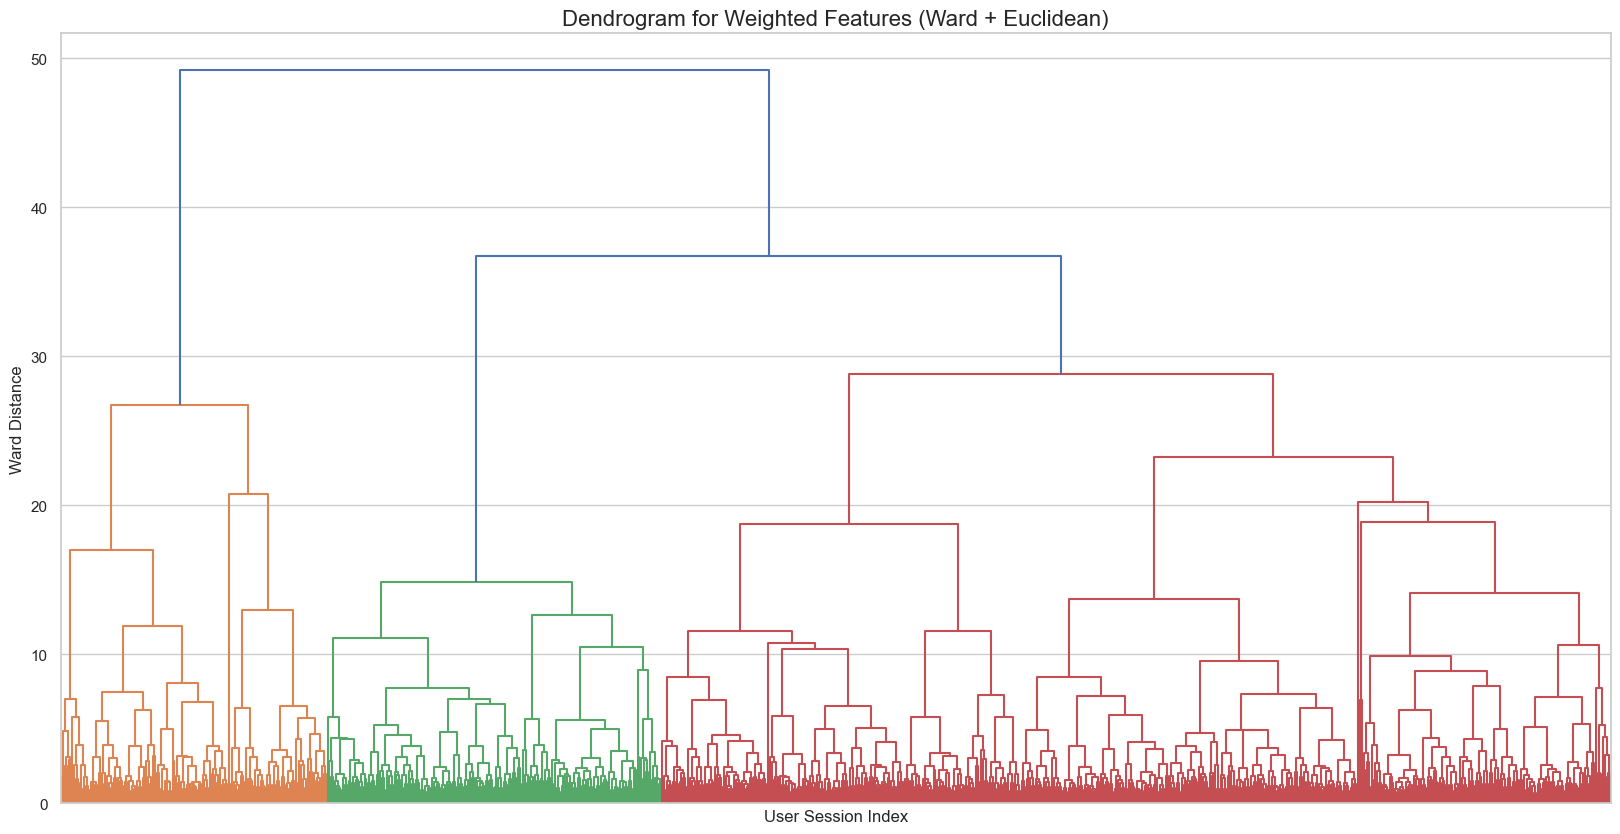

In [4]:
plt.figure(figsize=(20, 10))
plt.title('Dendrogram for Weighted Features (Ward + Euclidean)', fontsize=16)
plt.xlabel('User Session Index', fontsize=12)
plt.ylabel('Ward Distance', fontsize=12)

dendrogram(
    Z,
    leaf_rotation=90.,
    leaf_font_size=8.,
    no_labels=True
)

plt.show()

### Cluster Purity Heatmap

Visualizing the alignment between actual users and discovered clusters for the first 20 users.

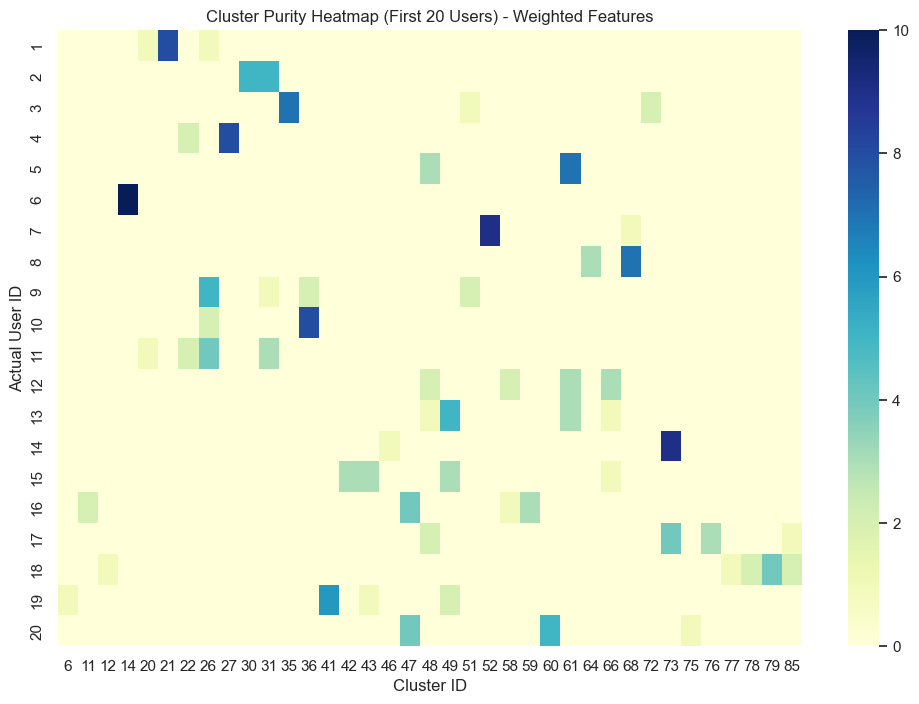

In [5]:
comparison_df = pd.DataFrame({
    'True_User': y_true,
    'Cluster': clusters
})

plt.figure(figsize=(12, 8))
subset_users = comparison_df[comparison_df['True_User'] <= 20]
contingency_matrix = pd.crosstab(subset_users['True_User'], subset_users['Cluster'])
sns.heatmap(contingency_matrix, annot=False, cmap="YlGnBu")
plt.title('Cluster Purity Heatmap (First 20 Users) - Weighted Features')
plt.xlabel('Cluster ID')
plt.ylabel('Actual User ID')
plt.show()

## 4. Full Quality Analysis

Comparing the clusters discovered against the true user identities for the entire dataset.

Overall Cluster Purity: 0.5068
Adjusted Rand Index: 0.3356
Users perfectly clustered: 5 out of 88


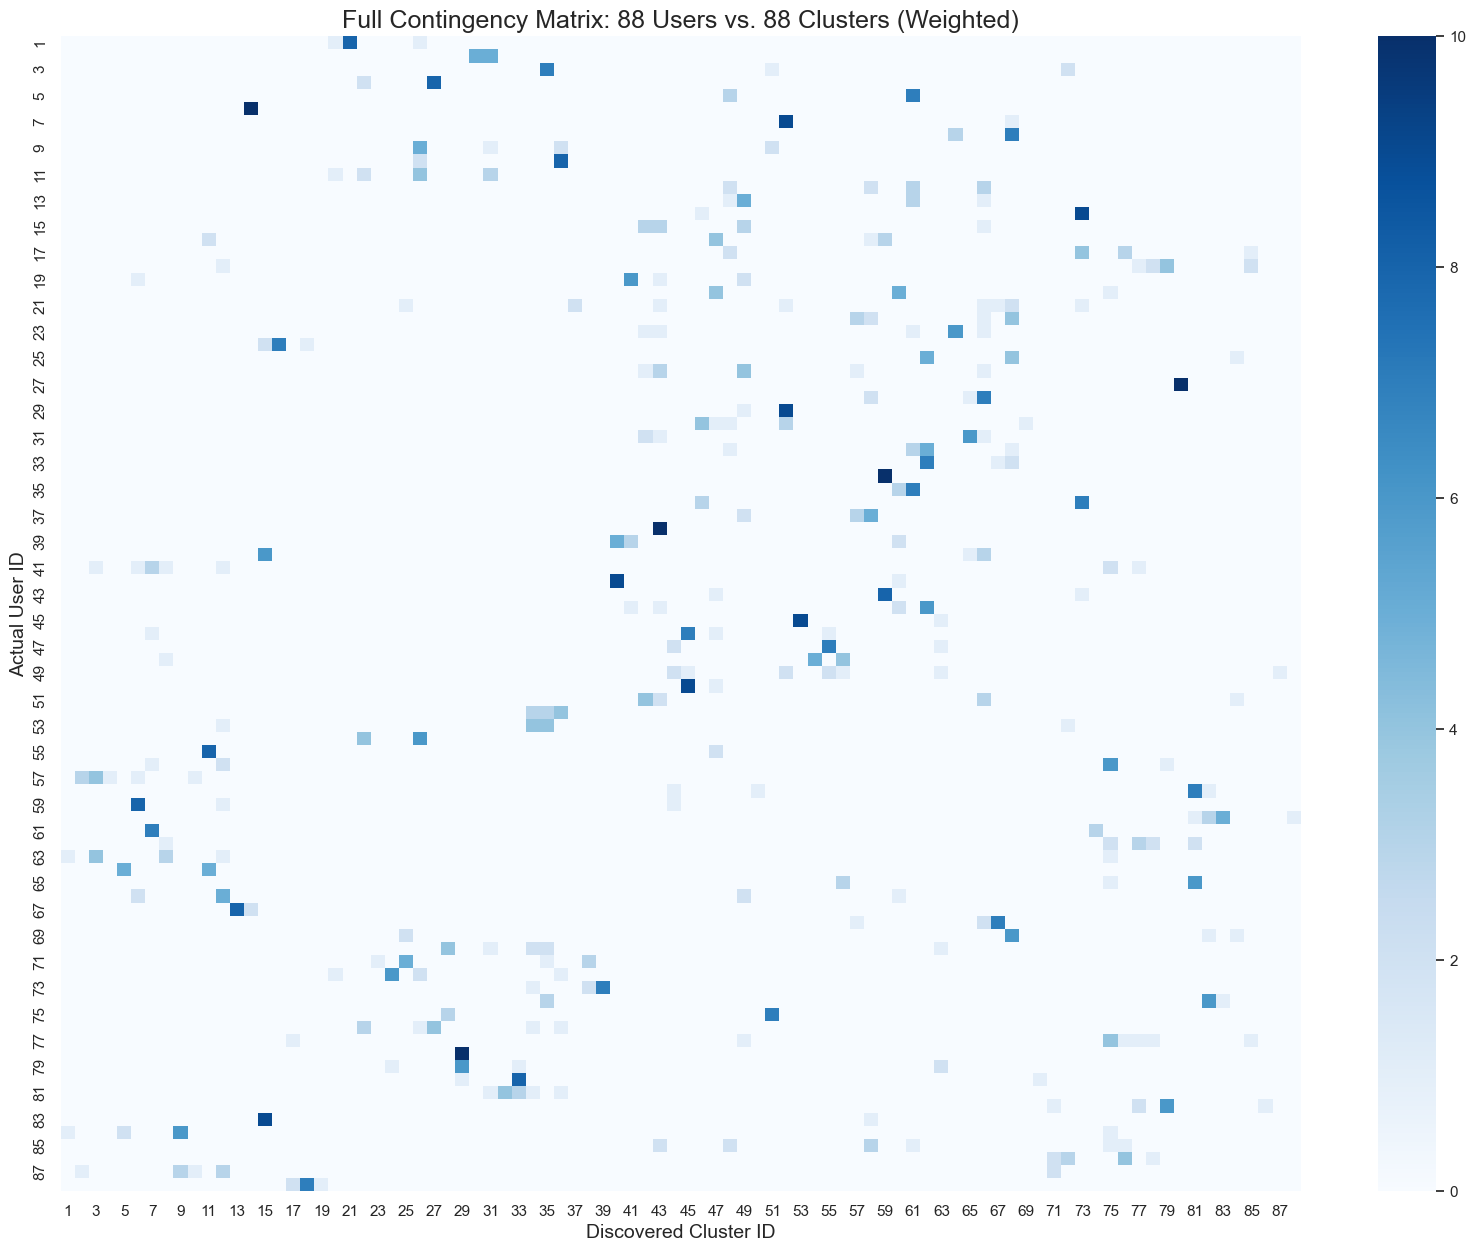

In [6]:
def calculate_purity(df):
    correct_assignments = 0
    for cluster in df['Cluster'].unique():
        cluster_users = df[df['Cluster'] == cluster]['True_User']
        if len(cluster_users) > 0:
            correct_assignments += cluster_users.value_counts().iloc[0]
    return correct_assignments / len(df)

purity = calculate_purity(comparison_df)

print(f"Overall Cluster Purity: {purity:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")

user_cluster_counts = comparison_df.groupby('True_User')['Cluster'].nunique()
perfect_users = user_cluster_counts[user_cluster_counts == 1]

print(f"Users perfectly clustered: {len(perfect_users)} out of 88")

# Full Contingency Heatmap
plt.figure(figsize=(20, 15))
full_contingency = pd.crosstab(comparison_df['True_User'], comparison_df['Cluster'])
sns.heatmap(full_contingency, cmap="Blues", cbar=True)
plt.title('Full Contingency Matrix: 88 Users vs. 88 Clusters (Weighted)', fontsize=18)
plt.xlabel('Discovered Cluster ID', fontsize=14)
plt.ylabel('Actual User ID', fontsize=14)
plt.show()